CsI Measurement

dated (22 May, 2025)

Setup:

For pedestal measurement setup:

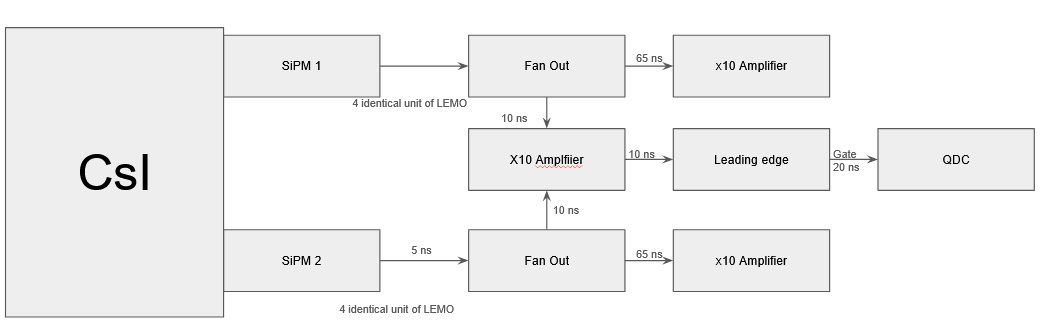

For single SiPM measurement setup:

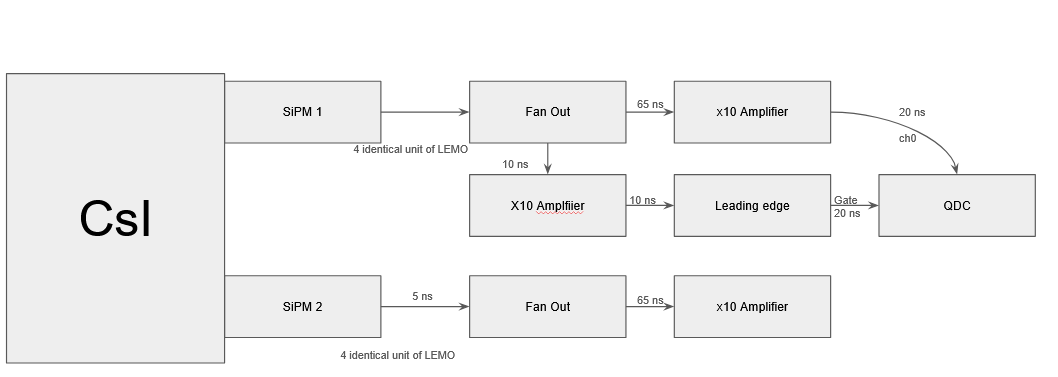

For coincidence setup:

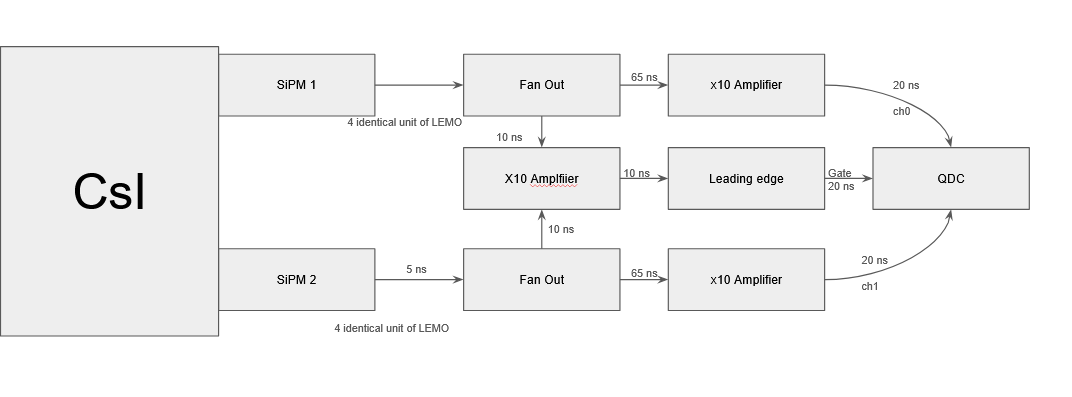

# Some calibration

By extending both SiPM signal by identical length cable, the current delay between the gate and signals 

For OR channel:

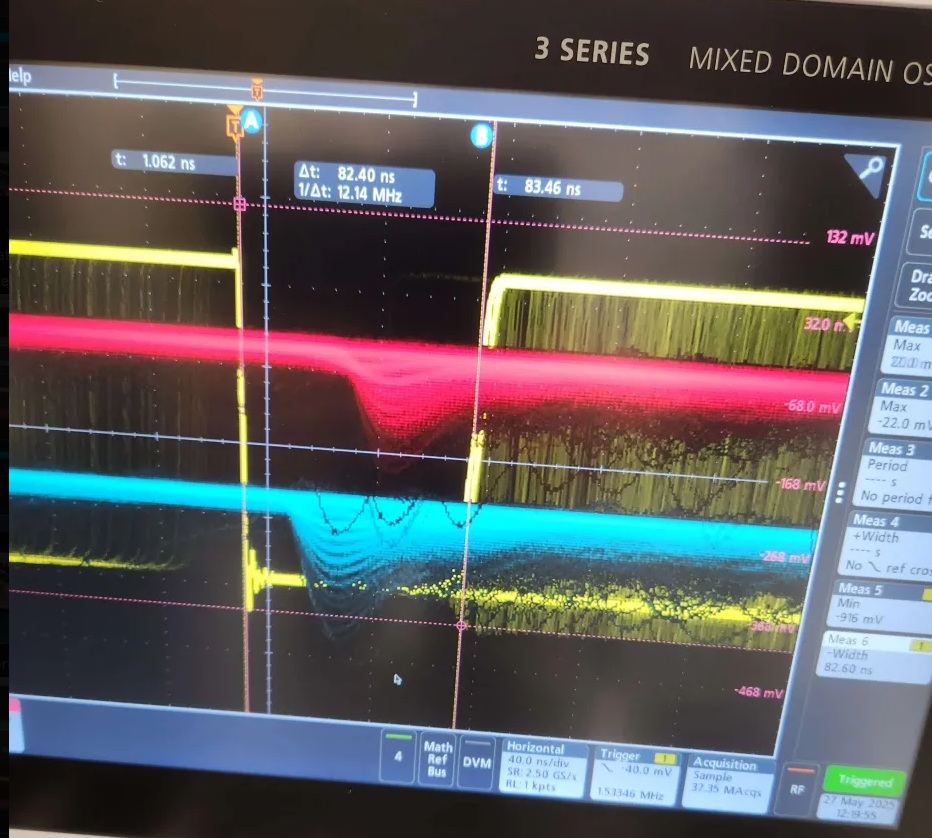

For majority:

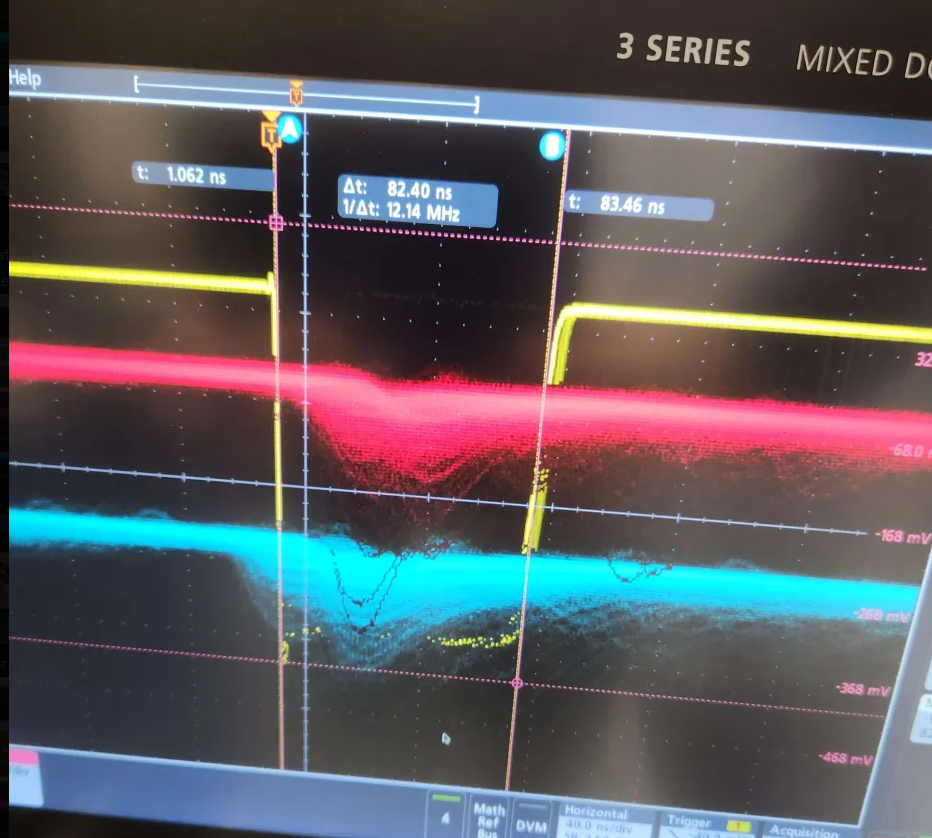

For considering grounding only:

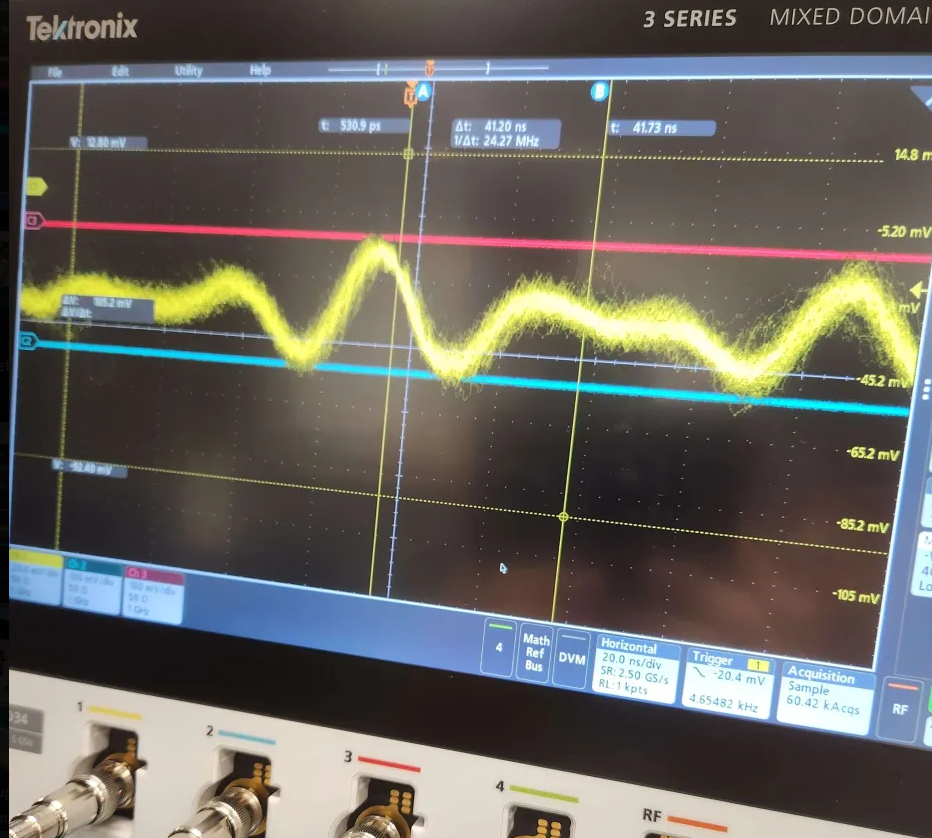

For the SiPM1 signal that feed into the discriminator channel 1 at trigger=-20 mV

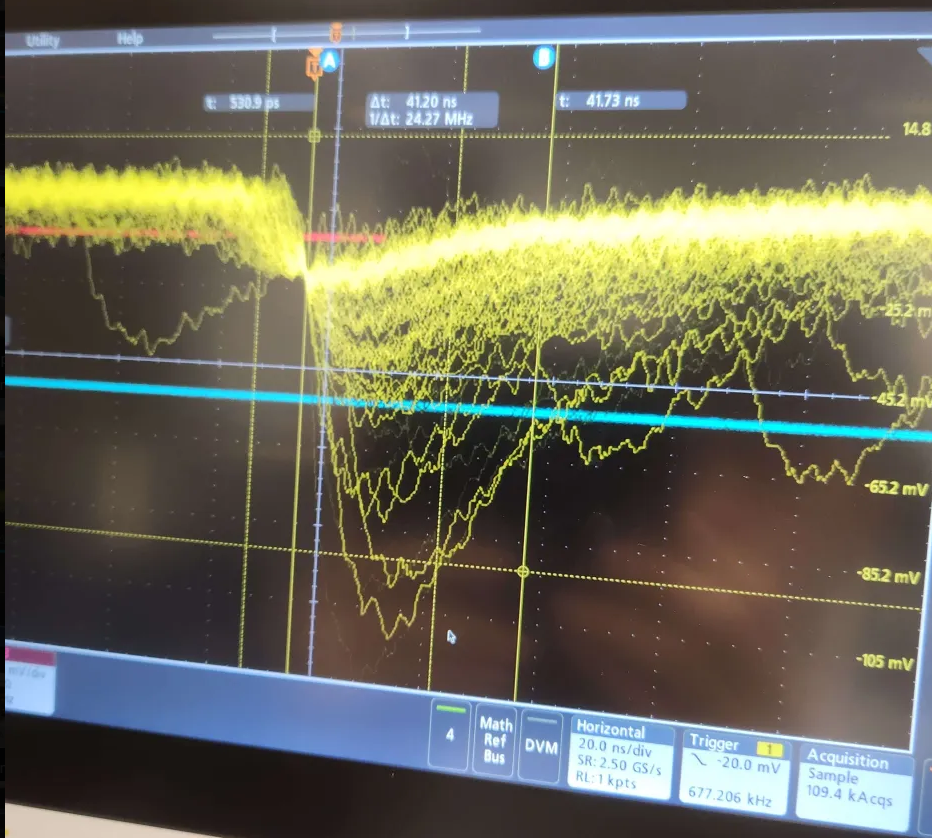

For the SiPM2 signal that feed into the discriminator channel 2 at trigger=-20 mV

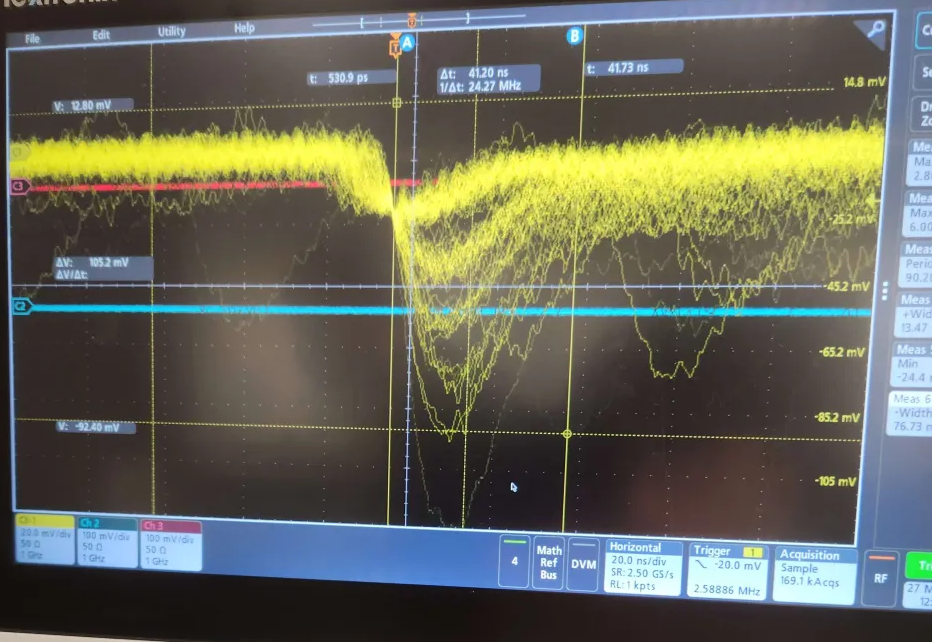

For the triggering rate of the gate

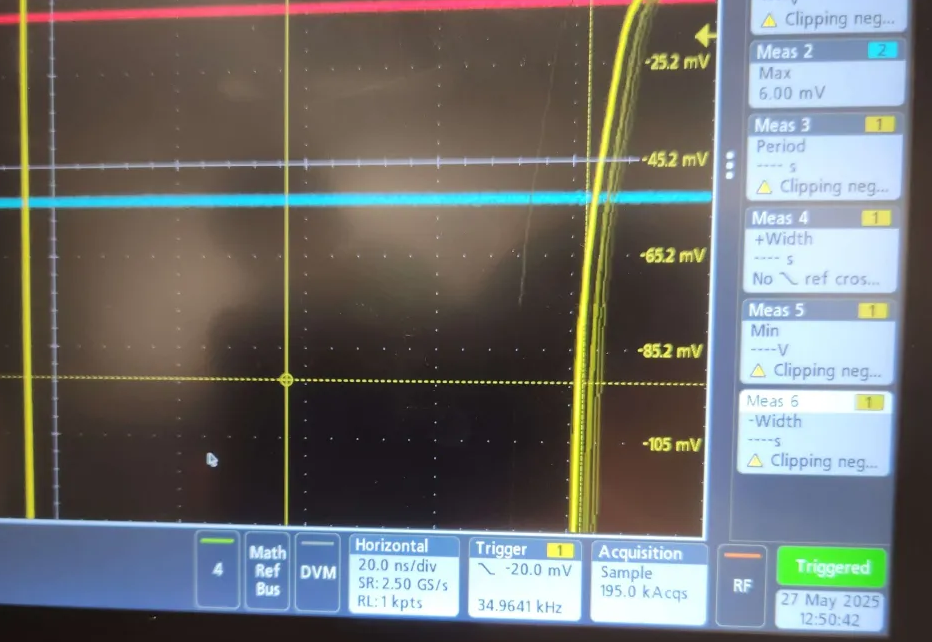

# Actual codes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import mplhep as hep
hep.style.use(hep.style.ROOT)

In [3]:
def plot_histogram_with_errorbars(series,name, plottype="step",bins="auto", color="skyblue", edgecolor="black"):
    """
    Plot a histogram from a pandas Series with Poisson error bars (sqrt of counts) on the main plot.
    Parameters:
    - series: pandas.Series, input data to plot
    - bins: int or sequence, number of bins or bin edges for histogram
    - figsize: tuple, figure size (width, height)
    - title: str, plot title
    - xlabel: str, x-axis label
    - ylabel: str, y-axis label
    - color: str, fill color of histogram bars
    - edgecolor: str, edge color of histogram bars
    Returns:
    - None (displays the plot directly)
    """
   # Create histogram
    counts, bin_edges = np.histogram(series, bins=bins)
    # Calculate bin centers for error bar positions
    bin_centers = (bin_edges[:-1] + bin_edges[1:])/2
    # Poisson error bars: sqrt of counts
    errors = np.sqrt(counts)
    
    # Plot histogram
    #plt.hist(series, bins=bins,histtype=plottype, color=color, edgecolor=edgecolor, label=name)
    plt.hist(series, bins=bins,histtype=plottype, label=name)

    # Plot error bars at bin centers
    #plt.errorbar(bin_centers, counts, yerr=errors, fmt='none', ecolor='red', 
    #             capsize=3, label="Poisson errors")
    plt.errorbar(bin_centers, counts, yerr=errors, fmt='none',ecolor='red', capsize=3)
    # Customize plot
    plt.legend()
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()

## Single Photon

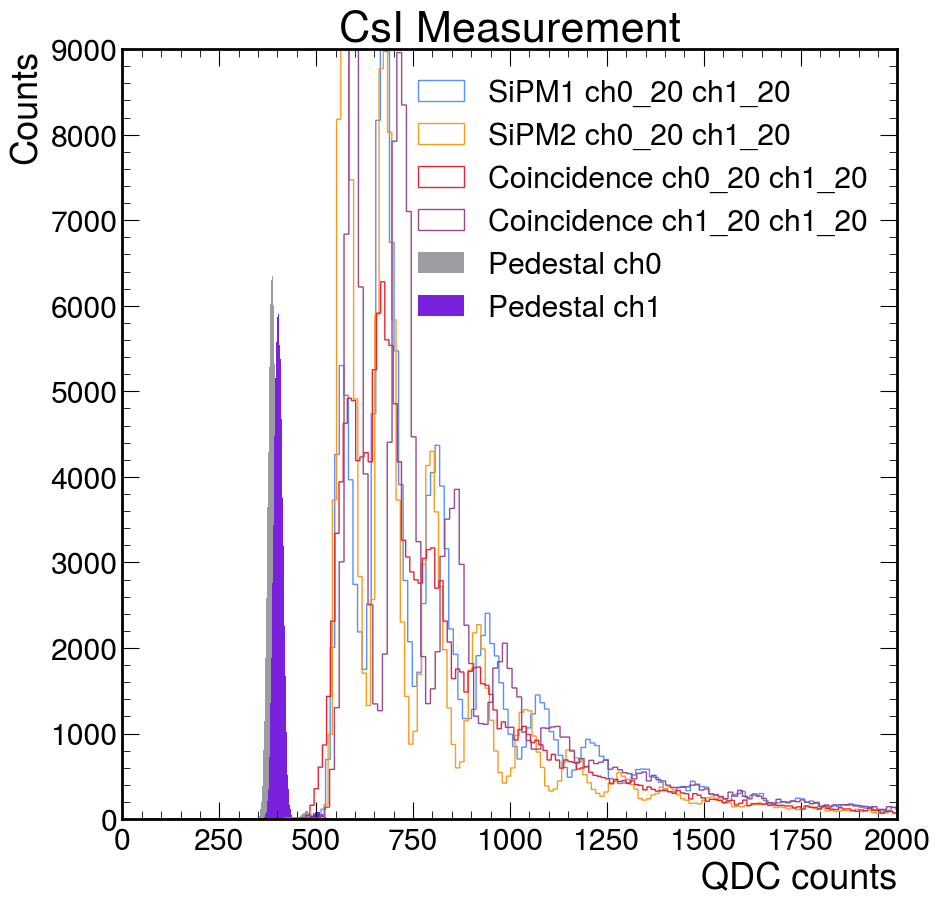

In [ ]:
SiPM1=pd.read_csv("CsI_DetachOnTape_LightOff/detach_SiPM1.txt",sep=" ")
SiPM2=pd.read_csv("CsI_DetachOnTape_LightOff/detach_SiPM2.txt",sep=" ")
Coincidence=pd.read_csv("CsI_DetachOnTape_LightOff/detach_Coincidence.txt",sep=" ")
Pedestal=pd.read_csv("pedestal.txt",sep=" ")
channel_consideration="ch1"
bins_num="auto"

plt.hist(SiPM1['ch0'], bins=bins_num,histtype='step',label="SiPM1 ch0_20 ch1_20")
plt.hist(SiPM2['ch1'], bins=bins_num,histtype='step',label="SiPM2 ch0_20 ch1_20")
#plt.hist(Coincidence['ch0'], bins=bins_num,histtype='step',label="Coincidence ch0_20 ch1_20")
#plt.hist(Coincidence['ch1'], bins=bins_num,histtype='step',label="Coincidence ch1_20 ch1_20")
plt.hist(Pedestal['ch0'], bins=bins_num,label="Pedestal ch0")
plt.hist(Pedestal['ch1'], bins=bins_num,label="Pedestal ch1")
plt.title("CsI Measurement")
plt.xlabel("QDC counts")
plt.ylabel("Counts")
plt.xlim(0,2000)
plt.ylim(0,9000)
plt.legend()
plt.show()

## Coincidence

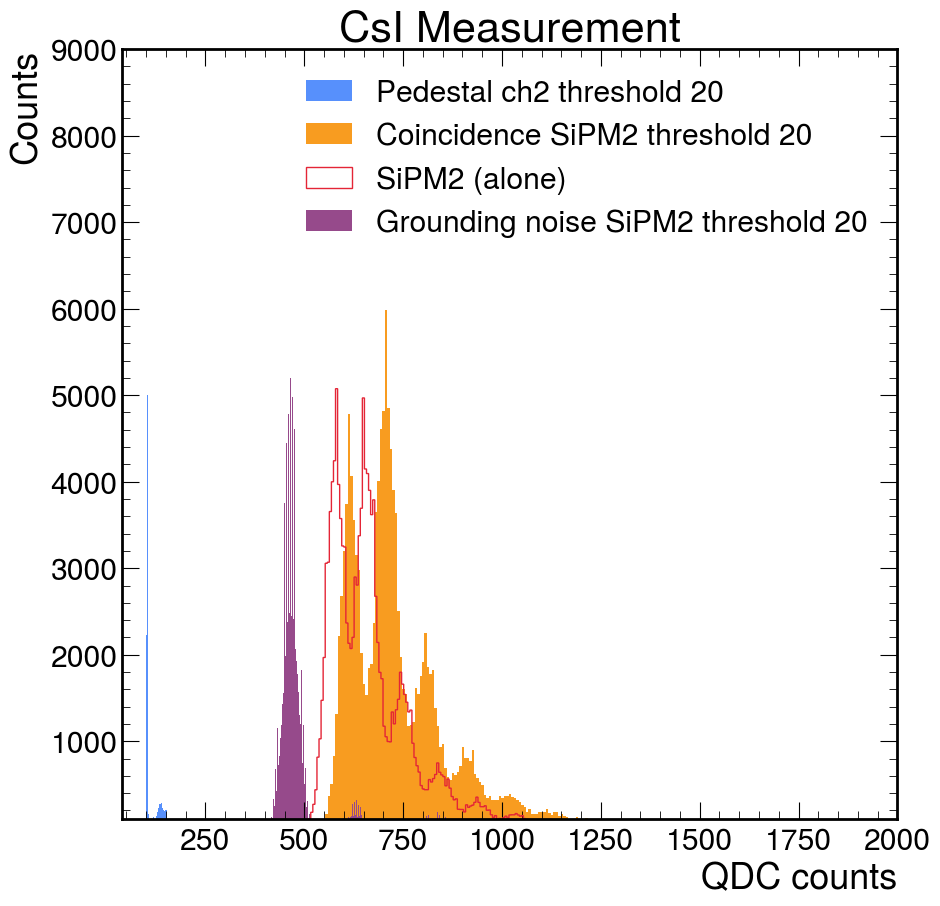

In [ ]:
coincidence_ch0_20_ch1_20=pd.read_csv("CsI_Measurement/2channel_coincidence_ch0_20_ch1_20.txt",sep=" ")
Pedestal=pd.read_csv("CsI_Measurement/2channel_pedestal_ch0_20_ch1_20.txt",sep=" ")
SiPM_Ground=pd.read_csv("CsI_Measurement/OffSiPMSupply_ch0_20_ch1_20.txt",sep=" ")
channel_consideration="ch1"
bins_num="auto"
plt.hist(Pedestal[channel_consideration], bins=bins_num,label="Pedestal ch2 threshold 20")
plt.hist(coincidence_ch0_20_ch1_20[channel_consideration], bins=bins_num,label="Coincidence SiPM2 threshold 20")
plt.hist(SiPM2[channel_consideration], bins=bins_num,histtype='step',label="SiPM2 (alone)")
plt.hist(SiPM_Ground[channel_consideration], bins=bins_num,label="Grounding noise SiPM2 threshold 20")
plt.title("CsI Measurement")
plt.xlabel("QDC counts")
plt.ylabel("Counts")
plt.xlim(40,2000)
plt.ylim(100,
         9000)
plt.legend()
plt.show()

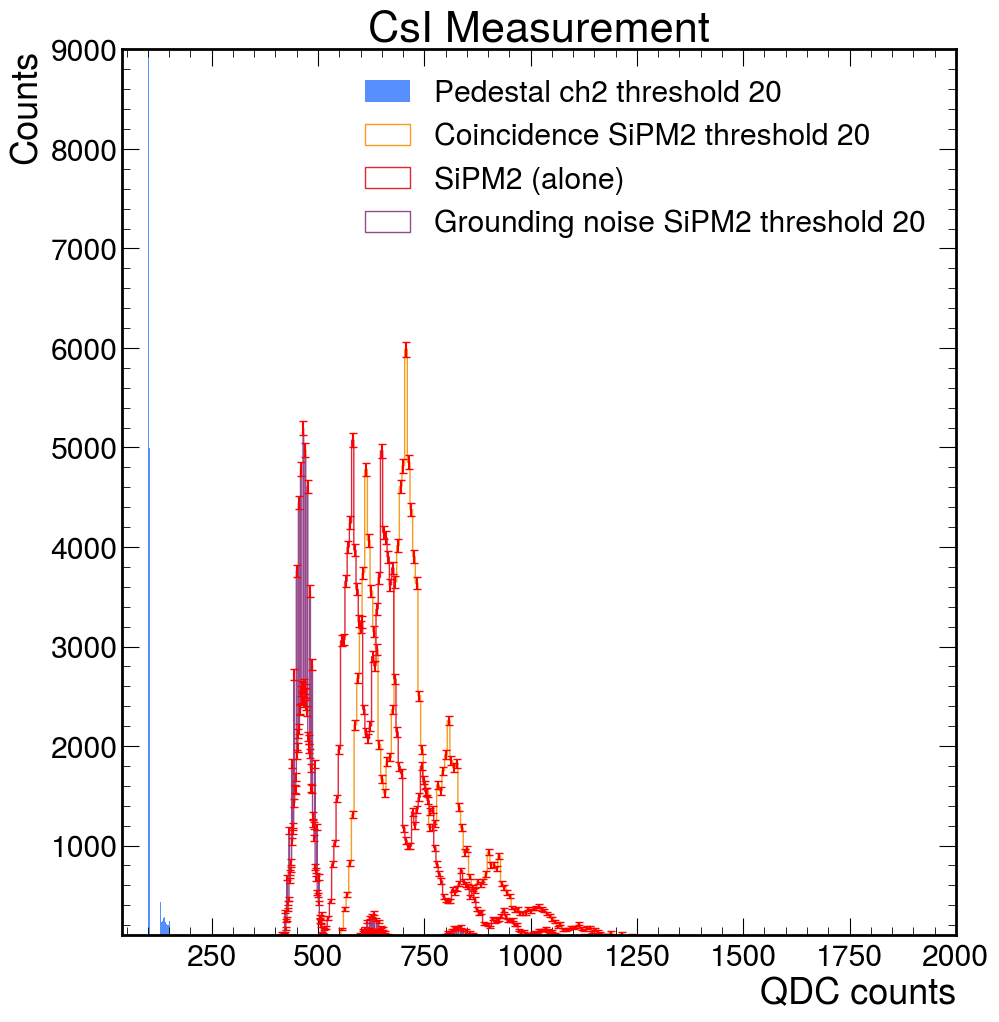

In [15]:
coincidence_ch0_20_ch1_20=pd.read_csv("CsI_Measurement/2channel_coincidence_ch0_20_ch1_20.txt",sep=" ")
Pedestal=pd.read_csv("CsI_Measurement/2channel_pedestal_ch0_20_ch1_20.txt",sep=" ")
SiPM_Ground=pd.read_csv("CsI_Measurement/OffSiPMSupply_ch0_20_ch1_20.txt",sep=" ")
channel_consideration="ch1"
bins_num="auto"
plt.hist(Pedestal[channel_consideration], bins=bins_num,label="Pedestal ch2 threshold 20")
plot_histogram_with_errorbars(coincidence_ch0_20_ch1_20[channel_consideration], "Coincidence SiPM2 threshold 20")
plot_histogram_with_errorbars(SiPM2[channel_consideration], "SiPM2 (alone)")
plot_histogram_with_errorbars(SiPM_Ground[channel_consideration], "Grounding noise SiPM2 threshold 20")
plt.title("CsI Measurement")
plt.xlabel("QDC counts")
plt.ylabel("Counts")
plt.xlim(40,2000)
plt.ylim(100,
         9000)
plt.legend()
plt.show()

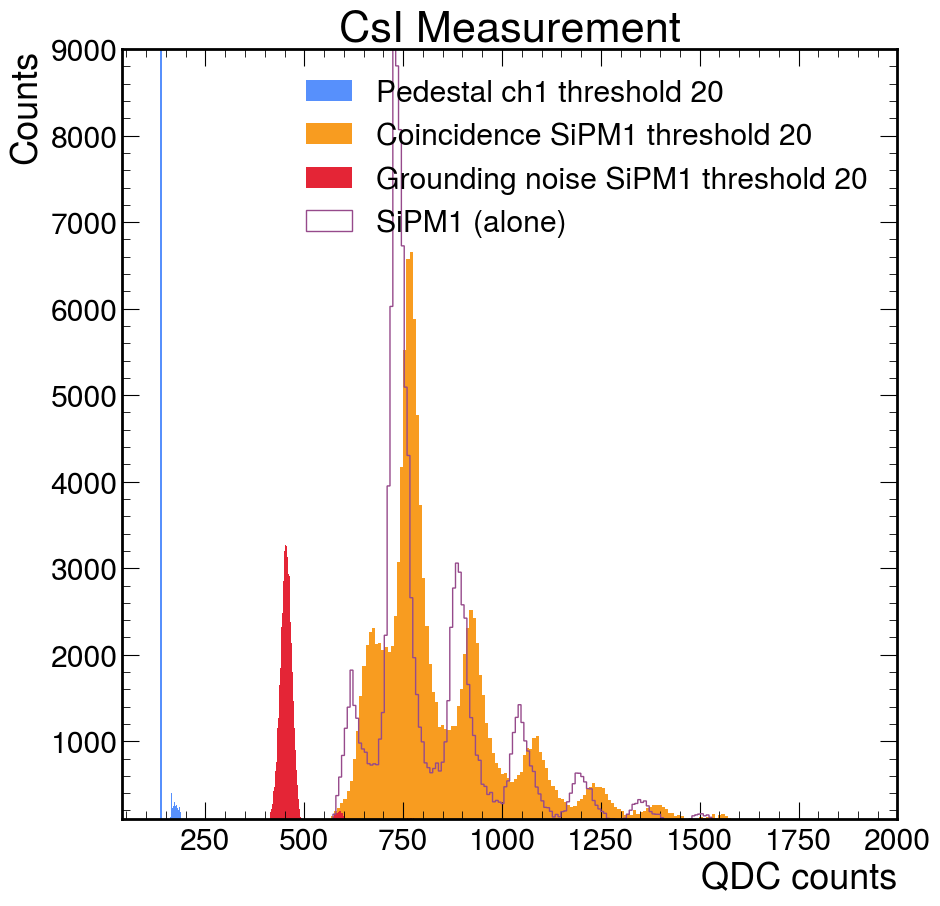

In [13]:
coincidence_ch0_20_ch1_20=pd.read_csv("CsI_Measurement/2channel_coincidence_ch0_20_ch1_20.txt",sep=" ")
Pedestal=pd.read_csv("CsI_Measurement/2channel_pedestal_ch0_20_ch1_20.txt",sep=" ")
SiPM_Ground=pd.read_csv("CsI_Measurement/OffSiPMSupply_ch0_20_ch1_20.txt",sep=" ")

channel_consideration="ch0"
bins_num="auto"
plt.hist(Pedestal[channel_consideration], bins=bins_num,label="Pedestal ch1 threshold 20")
plt.hist(coincidence_ch0_20_ch1_20[channel_consideration], bins=bins_num,label="Coincidence SiPM1 threshold 20")
plt.hist(SiPM_Ground[channel_consideration], bins=bins_num,label="Grounding noise SiPM1 threshold 20")
plt.hist(SiPM1[channel_consideration], bins=bins_num,histtype='step',label="SiPM1 (alone)")

plt.title("CsI Measurement")
plt.xlabel("QDC counts")
plt.ylabel("Counts")
plt.xlim(40,2000)
plt.ylim(100,
         9000)
plt.legend()
plt.show()

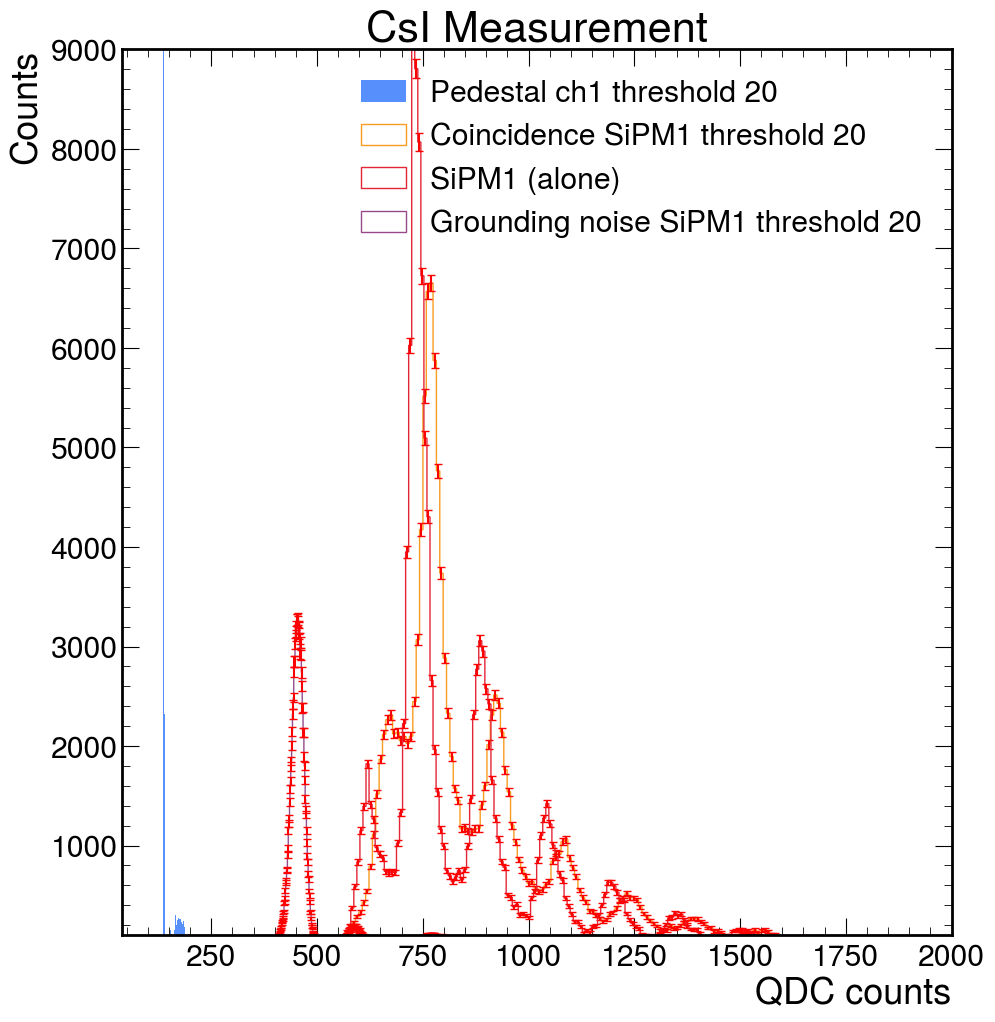

In [17]:
coincidence_ch0_20_ch1_20=pd.read_csv("CsI_Measurement/2channel_coincidence_ch0_20_ch1_20.txt",sep=" ")
Pedestal=pd.read_csv("CsI_Measurement/2channel_pedestal_ch0_20_ch1_20.txt",sep=" ")
SiPM_Ground=pd.read_csv("CsI_Measurement/OffSiPMSupply_ch0_20_ch1_20.txt",sep=" ")

channel_consideration="ch0"
bins_num="auto"
plt.hist(Pedestal[channel_consideration], bins=bins_num,label="Pedestal ch1 threshold 20")
plot_histogram_with_errorbars(coincidence_ch0_20_ch1_20[channel_consideration], "Coincidence SiPM1 threshold 20")
plot_histogram_with_errorbars(SiPM1[channel_consideration], "SiPM1 (alone)")
plot_histogram_with_errorbars(SiPM_Ground[channel_consideration], "Grounding noise SiPM1 threshold 20")
plt.title("CsI Measurement")
plt.xlabel("QDC counts")
plt.ylabel("Counts")
plt.xlim(40,2000)
plt.ylim(100,
         9000)
plt.legend()
plt.show()

Casual estimation (later will have a geant4 simulation): The mean energy of cosmic muon are 4 GeV ^1, we can suppose the main energy loss be due to ionization loss, hence bethe-bloch equation applies. Substitute parameters from ^2, we see that the average energy loss is 7.94 MeV/cm, for our case, which muon travels for 5 cm, meaning an average of 39.7 MeV energy deposition.


According to ^1, using the light yield of their pure CsI is of 20 ph/MeV, we can calculate with the procedure
- Find the energy deposition of the muon particle in our detector
- Multiply this number by the light yield of the crystal
- account for the SiPM PDE
- note, we assumed all scintillation photon can be reached(may not be true as they can be attenuated) and detected by our SiPM(Not true again, as we only covered 0.01 fraction of the 5x5 face)
 and obtain and obtaining 794 ph, by ^5, we have the peak wavelength center at 315 nm, corresponding a PDE of ~40%, after PDE then 317.6ph.

Simulation: Using CsI crystal with our dimensions, we shoot cosmic ray, which energy and angular distribution follows by ^6 10 cm above the crystal face 5x50 cm2. with 1000000 number of such cosmic muon generated. The result can be seen below, with titile Pure CsI, CsI(Na), CsI(Ti), the computation is based on datas on ^5; KTeV CsI is based on ^1.


^1: A. Roodman. (1996). THE KTeV Pure CsI Calorimeter (ICHEP' 96). CERN. https://cds.cern.ch/record/318646/files/SCAN-9701177.pdf

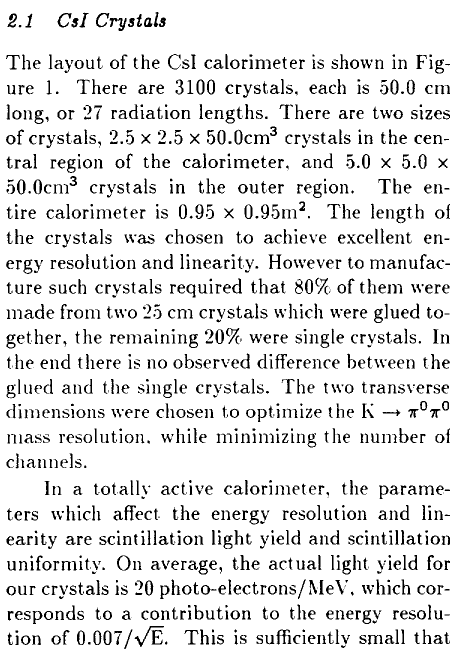

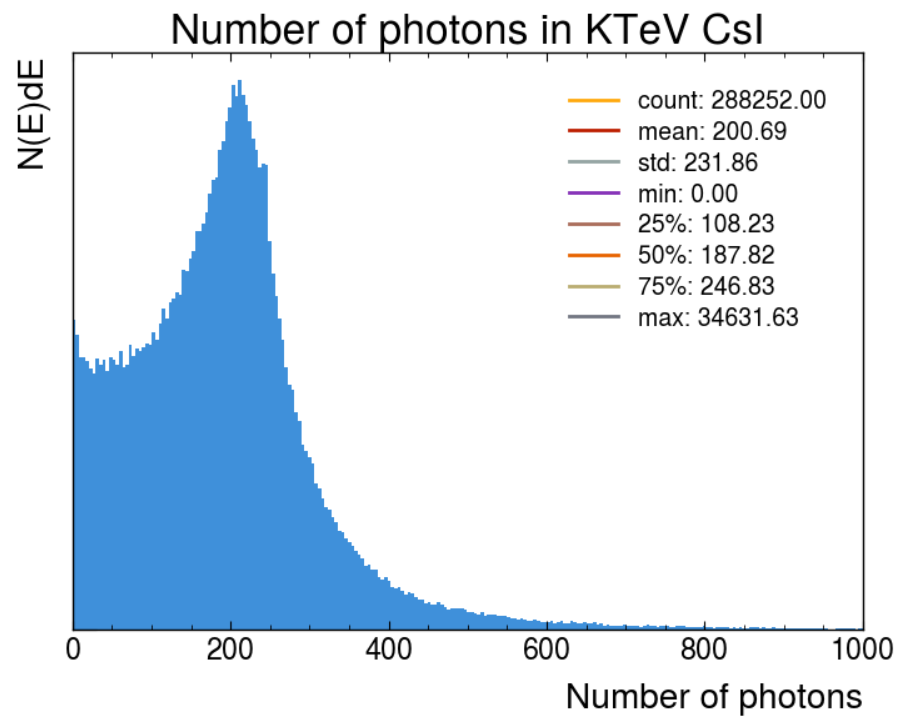